In [ ]:
# import tabula

In [ ]:
# import pdfplumber
# import pandas as pd
# import re

# def extract_robust_dataset(pdf_path):
#     a1_data = []
#     a2_data = []
#     valid_families = ['CER', 'ENSI', 'LCM', 'MAN', 'SLU']

#     # Force spatial text alignment
#     table_settings = {
#         "vertical_strategy": "text",
#         "horizontal_strategy": "text"
#     }

#     with pdfplumber.open(pdf_path) as pdf:
#         # Extract Table A1 (Pages 14-19 of the PDF -> zero-indexed 13-18)
#         for i in range(13, 19):
#             tables = pdf.pages[i].extract_tables(table_settings)
#             for table in tables:
#                 a1_data.extend(table)
                
#         # Extract Table A2 (Pages 20-24 of the PDF -> zero-indexed 19-23)
#         for i in range(19, 24):
#             tables = pdf.pages[i].extract_tables(table_settings)
#             for table in tables:
#                 a2_data.extend(table)

#     df_a1 = pd.DataFrame(a1_data)
#     df_a2 = pd.DataFrame(a2_data)

#     # Filter out header/page artifacts by ensuring Column 0 is a known Family
#     df_a1_clean = df_a1[df_a1[0].isin(valid_families)].copy().reset_index(drop=True)
#     df_a2_clean = df_a2[df_a2[0].isin(valid_families)].copy().reset_index(drop=True)

#     parsed_rows = []
    
#     # Iterate through matched rows in both tables simultaneously
#     for idx in range(len(df_a1_clean)):
        
#         # Flatten the entire row into a single string to destroy column misalignment
#         row_a1_str = " ".join(df_a1_clean.iloc[idx].dropna().astype(str))
#         row_a2_str = " ".join(df_a2_clean.iloc[idx].dropna().astype(str))
        
#         # Extract all sequential numbers (integers or decimals)
#         nums_a1 = re.findall(r'\d+\.\d+|\d+', row_a1_str)
#         nums_a2 = re.findall(r'\d+\.\d+|\d+', row_a2_str)
        
#         # Ensure the row parsed successfully before extracting by structural index
#         if len(nums_a1) >= 5 and len(nums_a2) >= 8:
#             parsed_rows.append({
#                 'Family': df_a1_clean.iloc[idx, 0],
#                 'Type': df_a1_clean.iloc[idx, 1].replace('\n', ' '),
#                 # Table A1 structure: [0]DM, [1]VS, [2]VS/DM, [3]BMP_SD, [4]BMP_Mean
#                 'BMP_exp_Mean': max(float(nums_a1[3]), float(nums_a1[4])),
#                 # Table A2 structure: [0,1]Cellulose, [2,3]Hemi, [4,5]Lignin, [6]Protein, [7]COD
#                 'Cellulose_Mean': max(float(nums_a2[0]), float(nums_a2[1])),
#                 'Hemicellulose_Mean': max(float(nums_a2[2]), float(nums_a2[3])),
#                 'Lignin_Mean': max(float(nums_a2[4]), float(nums_a2[5])),
#                 'Protein_Mean': float(nums_a2[6]),
#                 'COD_Mean': float(nums_a2[7])
#             })
            
#     return pd.DataFrame(parsed_rows)

# # --- Execution ---
# pdf_file = "waste-01-00014 (1).pdf"
# dataset = extract_robust_dataset(pdf_file)

# # Separate into standard X (features) and y (target) arrays
# X = dataset[['Cellulose_Mean', 'Hemicellulose_Mean', 'Lignin_Mean', 'Protein_Mean', 'COD_Mean']].values
# y = dataset['BMP_exp_Mean'].values

# print(f"Extracted Array X shape: {X.shape}")
# print(f"Extracted Array y shape: {y.shape}")
# print("\nFirst 5 rows of formatted DataFrame:")
# dataset.head()

In [8]:
import pdfplumber
import pandas as pd
import re

def extract_ultimate_dataset(pdf_path):
    a1_data = []
    a2_data = []
    valid_families = ['CER', 'ENSI', 'LCM', 'MAN', 'SLU']

    # Force spatial text alignment
    table_settings = {
        "vertical_strategy": "text",
        "horizontal_strategy": "text"
    }

    print("Extracting pages 14-24...")
    with pdfplumber.open(pdf_path) as pdf:
        # Extract Table A1
        for i in range(13, 19):
            for table in pdf.pages[i].extract_tables(table_settings):
                a1_data.extend(table)
                
        # Extract Table A2
        for i in range(19, 24):
            for table in pdf.pages[i].extract_tables(table_settings):
                a2_data.extend(table)

    df_a1 = pd.DataFrame(a1_data)
    df_a2 = pd.DataFrame(a2_data)

    # Filter out header/page artifacts
    df_a1_clean = df_a1[df_a1[0].isin(valid_families)].copy().reset_index(drop=True)
    df_a2_clean = df_a2[df_a2[0].isin(valid_families)].copy().reset_index(drop=True)

    parsed_rows = []
    
    # Iterate through matched rows simultaneously
    for idx in range(len(df_a1_clean)):
        
        # Flatten the row to destroy empty-cell column shifts
        row_a1_str = " ".join(df_a1_clean.iloc[idx].dropna().astype(str))
        row_a2_str = " ".join(df_a2_clean.iloc[idx].dropna().astype(str))
        
        # Extract all sequential floats/integers
        nums_a1 = [float(n) for n in re.findall(r'\d+\.\d+|\d+', row_a1_str)]
        nums_a2 = [float(n) for n in re.findall(r'\d+\.\d+|\d+', row_a2_str)]
        
        # Table A1 has ~17 numbers, Table A2 has ~8 numbers. 
        # We use reverse indexing (nums[-1]) to anchor to the end of the row, 
        # bypassing any messy text or variable numbers of SDs at the start.
        if len(nums_a1) >= 15 and len(nums_a2) >= 8:
            try:
                parsed_rows.append({
                    'Family': df_a1_clean.iloc[idx, 0],
                    'Type': df_a1_clean.iloc[idx, 1].replace('\n', ' '),
                    
                    # Target Variable (Forward Indexing from A1)
                    'BMP_exp_Mean': max(nums_a1[3], nums_a1[4]),
                    
                    # Physical Properties (Forward Indexing from A1)
                    'DM_Mean': nums_a1[0],
                    'VS_Mean': nums_a1[1],
                    
                    # Ultimate Analysis (Reverse Indexing from A1 end)
                    # Expected End: C/N, C(sd,mean), H(sd,mean), N(sd,mean), S(sd,mean), O
                    'Oxygen_Mean': nums_a1[-1],
                    'Sulfur_Mean': max(nums_a1[-2], nums_a1[-3]),
                    'Nitrogen_Mean': max(nums_a1[-4], nums_a1[-5]),
                    'Hydrogen_Mean': max(nums_a1[-6], nums_a1[-7]),
                    'Carbon_Mean': max(nums_a1[-8], nums_a1[-9]),
                    'C_N_Ratio': nums_a1[-10],
                    
                    # Fiber & Proximate Analysis (Reverse Indexing from A2 end)
                    # Expected End: Cell(sd,mean), Hemi(sd,mean), Lig(sd,mean), Prot, COD
                    'COD_Mean': nums_a2[-1],
                    'Protein_Mean': nums_a2[-2],
                    'Lignin_Mean': max(nums_a2[-3], nums_a2[-4]),
                    'Hemicellulose_Mean': max(nums_a2[-5], nums_a2[-6]),
                    'Cellulose_Mean': max(nums_a2[-7], nums_a2[-8])
                })
            except IndexError:
                # Silently skip any catastrophically malformed rows
                continue
            
    return pd.DataFrame(parsed_rows)

# --- Execution ---
pdf_file = "waste-01-00014 (1).pdf"
dataset = extract_ultimate_dataset(pdf_file)

# Save to CSV for your ML pipeline
dataset.to_csv("extracted_ultimate_bmp_dataset.csv", index=False)

print(f"Extraction Complete. Final Matrix Shape: {dataset.shape}")
print("\n--- Feature Space ---")
print(dataset.columns.tolist())
print("\n--- First 3 Rows ---")
print(dataset.head(3).to_string())

Extracting pages 14-24...
Extraction Complete. Final Matrix Shape: (132, 16)

--- Feature Space ---
['Family', 'Type', 'BMP_exp_Mean', 'DM_Mean', 'VS_Mean', 'Oxygen_Mean', 'Sulfur_Mean', 'Nitrogen_Mean', 'Hydrogen_Mean', 'Carbon_Mean', 'C_N_Ratio', 'COD_Mean', 'Protein_Mean', 'Lignin_Mean', 'Hemicellulose_Mean', 'Cellulose_Mean']

--- First 3 Rows ---
  Family     Type  BMP_exp_Mean  DM_Mean  VS_Mean  Oxygen_Mean  Sulfur_Mean  Nitrogen_Mean  Hydrogen_Mean  Carbon_Mean  C_N_Ratio  COD_Mean  Protein_Mean  Lignin_Mean  Hemicellulose_Mean  Cellulose_Mean
0   ENSI   Millet         267.9     22.9     20.8         41.9          0.2            0.8            5.3         42.7       54.1       1.3           4.9         22.3                17.7             8.6
1   ENSI  Sorghum         361.8     18.4     16.2         38.5          0.3            1.5            5.6         42.3       28.2       1.4           9.4         21.1                10.8             1.7
2   ENSI      Mix         406.0     1

In [9]:
dataset.head()

,Family,Type,BMP_exp_Mean,DM_Mean,VS_Mean,Oxygen_Mean,Sulfur_Mean,Nitrogen_Mean,Hydrogen_Mean,Carbon_Mean,C_N_Ratio,COD_Mean,Protein_Mean,Lignin_Mean,Hemicellulose_Mean,Cellulose_Mean
0,ENSI,Millet,267.9,22.9,20.8,41.9,0.2,0.8,5.3,42.7,54.1,1.3,4.9,22.3,17.7,8.6
1,ENSI,Sorghum,361.8,18.4,16.2,38.5,0.3,1.5,5.6,42.3,28.2,1.4,9.4,21.1,10.8,1.7
2,ENSI,Mix,406.0,16.5,14.9,38.8,0.3,2.3,6.0,43.1,19.1,1.4,14.1,19.4,12.7,2.7
3,ENSI,Sorghum,351.3,15.5,14.3,41.8,0.2,1.7,6.0,42.6,25.1,1.3,10.6,18.1,12.1,5.1
4,ENSI,Sorghum,360.4,16.1,14.8,39.9,0.2,2.2,5.9,43.4,19.5,1.4,13.9,20.0,13.7,2.8


In [10]:
dataset.columns.tolist()

['Family',
 'Type',
 'BMP_exp_Mean',
 'DM_Mean',
 'VS_Mean',
 'Oxygen_Mean',
 'Sulfur_Mean',
 'Nitrogen_Mean',
 'Hydrogen_Mean',
 'Carbon_Mean',
 'C_N_Ratio',
 'COD_Mean',
 'Protein_Mean',
 'Lignin_Mean',
 'Hemicellulose_Mean',
 'Cellulose_Mean']

In [ ]:
# ── Install dependencies (uncomment if running on Colab) ─────────────
# !pip install -q xgboost lightgbm catboost pytorch-tabnet gplearn shap

--- 5-Fold Cross-Validation (Training Set) ---
R2 Scores per fold: [0.35665375 0.38710285 0.09599868 0.30508311 0.40555148]
Mean CV R2: 0.3101 (+/- 0.1123)
Mean CV RMSE: 55.3106 Nml/g VS

--- Test Set Evaluation (20% Holdout) ---
Test R2 Score: 0.3289
Test RMSE:     37.3262 Nml/g VS
Test MAE:      29.1091 Nml/g VS

--- Feature Importance (Information Gain) ---
                    Feature  Importance
              Hydrogen_Mean    0.111662
                    DM_Mean    0.096434
               Total_Fibers    0.088470
                Lignin_Mean    0.085100
                    VS_Mean    0.083534
        Recalcitrance_Index    0.068230
                   COD_Mean    0.056576
                Sulfur_Mean    0.048430
     Lignin_Cellulose_Ratio    0.044929
                Oxygen_Mean    0.040688
      Theoretical_Yield_Nml    0.035666
                Carbon_Mean    0.034966
                  C_N_Ratio    0.034357
              Holocellulose    0.032467
Readily_Degradable_Fraction    0.0316

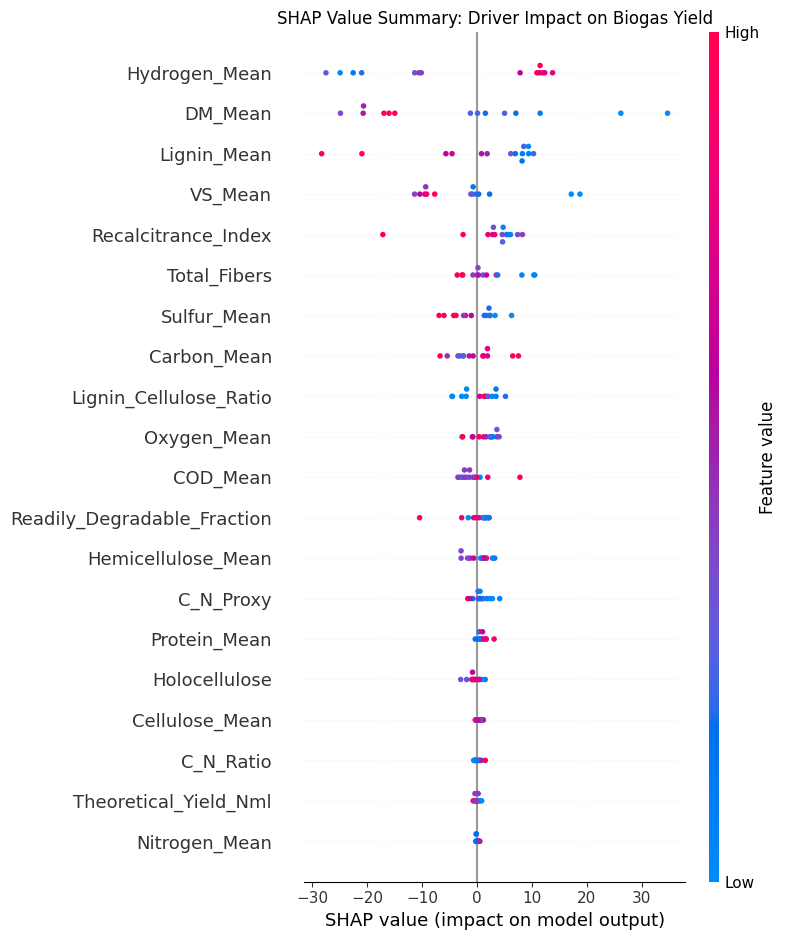

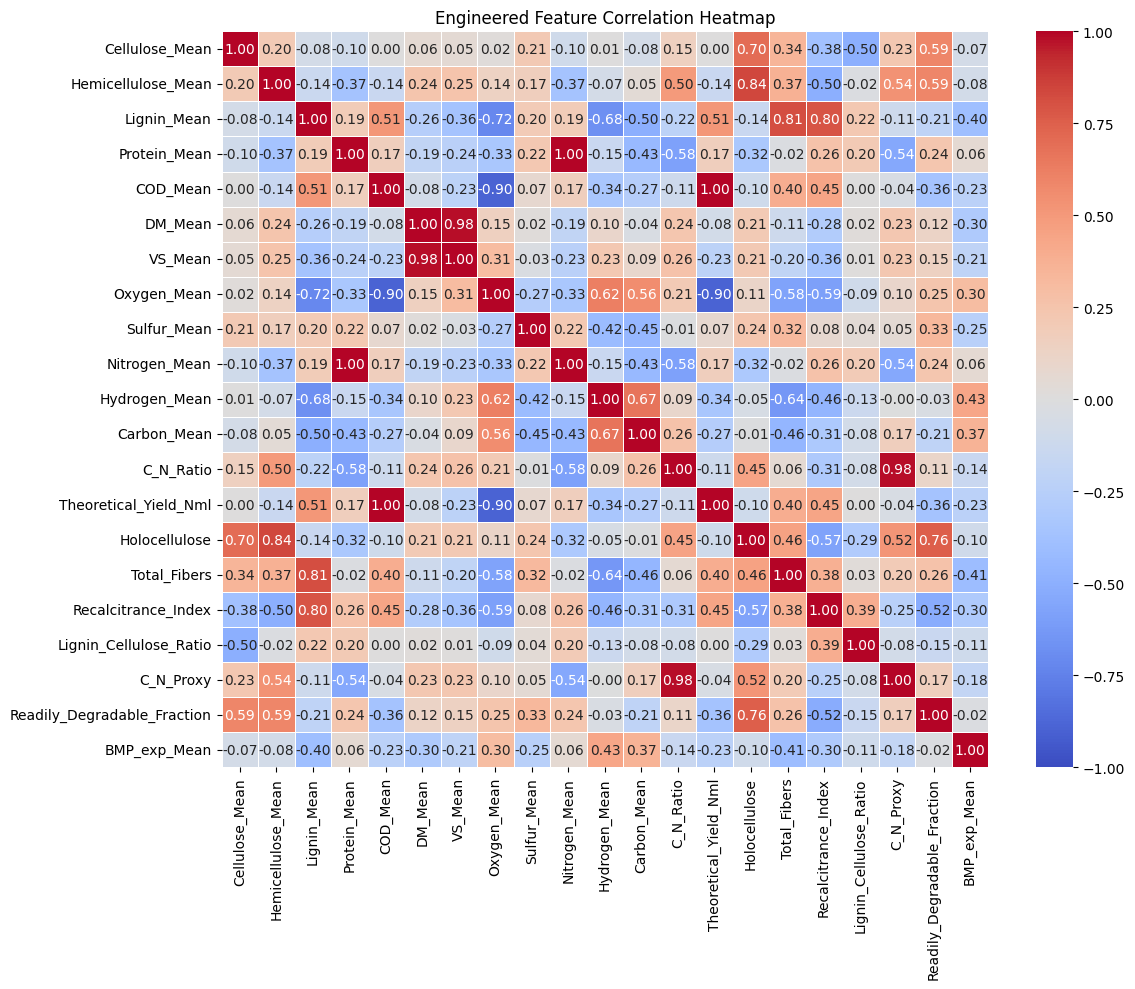

In [11]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------------------------------------------------------
# 1. LOAD & CLEAN DATA
# ---------------------------------------------------------
df =dataset.copy() # pd.read_csv('extracted_ultimate_bmp_dataset.csv')
# features = ['Cellulose_Mean', 'Hemicellulose_Mean', 'Lignin_Mean', 'Protein_Mean', 'COD_Mean']
# target = 'BMP_exp_Mean'
features = [
    'Cellulose_Mean', 
    'Hemicellulose_Mean', 
    'Lignin_Mean', 
    'Protein_Mean', 
    'COD_Mean',
    'DM_Mean', 
    'VS_Mean', 
    'Oxygen_Mean', 
    'Sulfur_Mean', 
    'Nitrogen_Mean', 
    'Hydrogen_Mean', 
    'Carbon_Mean', 
    'C_N_Ratio'
]

target = 'BMP_exp_Mean'

# Drop missing values to ensure array purity
df_clean = df.dropna(subset=features + [target]).copy()

# ---------------------------------------------------------
# 2. PHYSICS-INFORMED FEATURE ENGINEERING
# ---------------------------------------------------------
epsilon = 1e-6  # Mathematical constant to prevent ZeroDivisionError on pure substrates

# A. Thermodynamic Ceiling
df_clean['Theoretical_Yield_Nml'] = df_clean['COD_Mean'] * 350.0

# B. Macroscopic Structural Aggregations
df_clean['Holocellulose'] = df_clean['Cellulose_Mean'] + df_clean['Hemicellulose_Mean']
df_clean['Total_Fibers'] = df_clean['Holocellulose'] + df_clean['Lignin_Mean']

# C. Biochemical Recalcitrance & Shielding Penalties
df_clean['Recalcitrance_Index'] = df_clean['Lignin_Mean'] / (df_clean['Holocellulose'] + epsilon)
df_clean['Lignin_Cellulose_Ratio'] = df_clean['Lignin_Mean'] / (df_clean['Cellulose_Mean'] + epsilon)

# D. Stoichiometric & Kinetic Proxies
df_clean['C_N_Proxy'] = df_clean['Total_Fibers'] / (df_clean['Protein_Mean'] + epsilon)
df_clean['Readily_Degradable_Fraction'] = (df_clean['Holocellulose'] + df_clean['Protein_Mean']) / (df_clean['COD_Mean'] + epsilon)

# Define the highly-dimensional feature space
engineered_features = features + [
    'Theoretical_Yield_Nml', 'Holocellulose', 'Total_Fibers', 
    'Recalcitrance_Index', 'Lignin_Cellulose_Ratio', 'C_N_Proxy', 'Readily_Degradable_Fraction'
]

X = df_clean[engineered_features]
y = df_clean[target]

# ---------------------------------------------------------
# 3. XGBOOST REGULARIZATION & TRAINING
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42)

# Utilizing aggressive regularization (high subsample, low depth, heavy L2/alpha) 
# to prevent the trees from shattering the low-N (132) dataset space.
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=150,
    learning_rate=0.03,        # Slow learning rate for smoother optimization
    max_depth=3,               # Extremely shallow trees to prevent overfitting
    subsample=0.65,            # Stochastic sampling (row-wise)
    colsample_bytree=0.7,      # Stochastic sampling (column-wise)
    reg_lambda=1.5,            # L2 Regularization (Ridge)
    reg_alpha=0.5,             # L1 Regularization (Lasso)
    random_state=42
)

# 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2')
cv_rmse = cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')

print("--- 5-Fold Cross-Validation (Training Set) ---")
print(f"R2 Scores per fold: {cv_r2}")
print(f"Mean CV R2: {np.mean(cv_r2):.4f} (+/- {np.std(cv_r2):.4f})")
print(f"Mean CV RMSE: {-np.mean(cv_rmse):.4f} Nml/g VS\n")

# Final Fitting & Test Evaluation
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("--- Test Set Evaluation (20% Holdout) ---")
print(f"Test R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Test RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} Nml/g VS")
print(f"Test MAE:      {mean_absolute_error(y_test, y_pred):.4f} Nml/g VS\n")

# ---------------------------------------------------------
# 4. EXPLAINABLE AI (XAI) & VISUALIZATION
# ---------------------------------------------------------
# A. Standard XGBoost Gain
feature_imp_df = pd.DataFrame({'Feature': engineered_features, 'Importance': model.feature_importances_})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)
print("--- Feature Importance (Information Gain) ---")
print(feature_imp_df.to_string(index=False))

# B. SHAP Value Summary Plot (Deconstructs the mathematical impact of recalcitrance)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title('SHAP Value Summary: Driver Impact on Biogas Yield')
plt.tight_layout()
plt.savefig('shap_summary_engineered.png', dpi=300)
plt.show()

# C. Seaborn Correlation Heatmap of the New Features
plt.figure(figsize=(12, 10))
corr_matrix = df_clean[engineered_features + [target]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Engineered Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap_engineered.png', dpi=300)
plt.show()

# Small-Dataset Model Comparison (N = 132)

Models selected for their strong inductive biases, built-in regularization, or Bayesian priors — all properties that prevent overfitting on low-N tabular data.

**Evaluation protocol:** 5-Fold CV on training set + 20% holdout test set. All models use the same `X_train / X_test / y_train / y_test` split from the XGBoost cell above.

In [8]:
# ── Shared utilities for every model section ──────────────────────────
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np, warnings
warnings.filterwarnings('ignore')

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate(name, pipe, X_tr, y_tr, X_te, y_te):
    """Train, cross-validate, test, and print a compact report."""
    cv_r2   = cross_val_score(pipe, X_tr, y_tr, cv=kf, scoring='r2')
    cv_rmse = cross_val_score(pipe, X_tr, y_tr, cv=kf, scoring='neg_root_mean_squared_error')
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    test_r2   = r2_score(y_te, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    test_mae  = mean_absolute_error(y_te, y_pred)
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  CV R2:    {np.mean(cv_r2):.4f}  (+/- {np.std(cv_r2):.4f})")
    print(f"  CV RMSE:  {-np.mean(cv_rmse):.4f}")
    print(f"  Test R2:  {test_r2:.4f}")
    print(f"  Test RMSE:{test_rmse:.4f}")
    print(f"  Test MAE: {test_mae:.4f}\n")
    return {'Model': name, 'CV_R2_mean': np.mean(cv_r2), 'CV_R2_std': np.std(cv_r2),
            'Test_R2': test_r2, 'Test_RMSE': test_rmse, 'Test_MAE': test_mae,
            'y_pred': y_pred}

results = []  # accumulator for the final comparison table

## 1. Ridge Regression (L2-Regularized Linear Model)
Linear model with L2 penalty — extremely stable on small datasets because the penalty shrinks coefficients toward zero, preventing any single feature from dominating. The closed-form solution means no iterative convergence issues with N=132.

In [9]:
from sklearn.linear_model import Ridge

pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=10.0))
])
results.append(evaluate('Ridge Regression', pipe_ridge, X_train, y_train, X_test, y_test))

  Ridge Regression
  CV R2:    -0.0017  (+/- 0.2408)
  CV RMSE:  65.7047
  Test R2:  0.0214
  Test RMSE:45.0756
  Test MAE: 33.6288



## 2. Lasso Regression (L1-Regularized Linear Model)
L1 penalty drives irrelevant feature coefficients to exactly zero — acts as automatic feature selection. Ideal when you suspect some engineered features may be noise on a small sample.

In [10]:
from sklearn.linear_model import Lasso

pipe_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=1.0, max_iter=10000))
])
results.append(evaluate('Lasso Regression', pipe_lasso, X_train, y_train, X_test, y_test))

  Lasso Regression
  CV R2:    0.0140  (+/- 0.2184)
  CV RMSE:  65.2990
  Test R2:  0.0020
  Test RMSE:45.5200
  Test MAE: 33.9746



## 3. ElasticNet (L1 + L2 Combined)
Combines the sparsity of Lasso with the stability of Ridge. The `l1_ratio` controls the blend — a good default when you want feature selection without losing correlated feature groups entirely.

In [11]:
from sklearn.linear_model import ElasticNet

pipe_enet = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000))
])
results.append(evaluate('ElasticNet', pipe_enet, X_train, y_train, X_test, y_test))

  ElasticNet
  CV R2:    0.1189  (+/- 0.1269)
  CV RMSE:  62.9218
  Test R2:  0.0253
  Test RMSE:44.9849
  Test MAE: 33.8331



## 4. Bayesian Ridge Regression
Treats regression weights as probability distributions rather than point estimates. The model automatically tunes its own regularization strength via Bayesian evidence maximization — no manual alpha tuning needed. Natural uncertainty quantification is a bonus.

In [12]:
from sklearn.linear_model import BayesianRidge

pipe_bayes = Pipeline([
    ('scaler', StandardScaler()),
    ('model', BayesianRidge())
])
results.append(evaluate('Bayesian Ridge', pipe_bayes, X_train, y_train, X_test, y_test))

  Bayesian Ridge
  CV R2:    0.1062  (+/- 0.1321)
  CV RMSE:  63.3162
  Test R2:  0.0287
  Test RMSE:44.9067
  Test MAE: 33.7893



## 5. Support Vector Regression (SVR — RBF Kernel)
SVR with an RBF kernel maps data into infinite-dimensional space while controlling model complexity through the margin (C) and kernel width (gamma). The epsilon-tube ignores small errors, making it robust to noise — a common problem in small biogas datasets.

In [13]:
from sklearn.svm import SVR

pipe_svr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1))
])
results.append(evaluate('SVR (RBF)', pipe_svr, X_train, y_train, X_test, y_test))

  SVR (RBF)
  CV R2:    0.1571  (+/- 0.2158)
  CV RMSE:  62.2394
  Test R2:  -0.0501
  Test RMSE:46.6931
  Test MAE: 34.1664



## 6. K-Nearest Neighbors Regressor (KNN)
Non-parametric — makes zero assumptions about the data distribution. Predictions are the weighted average of the K closest training points. Works well on small datasets because every sample directly contributes to predictions. Distance weighting reduces sensitivity to K.

In [14]:
from sklearn.neighbors import KNeighborsRegressor

pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor(n_neighbors=7, weights='distance'))
])
results.append(evaluate('KNN (k=7)', pipe_knn, X_train, y_train, X_test, y_test))

  KNN (k=7)
  CV R2:    0.0467  (+/- 0.2186)
  CV RMSE:  64.4728
  Test R2:  -0.3477
  Test RMSE:52.8973
  Test MAE: 42.0421



## 7. Random Forest (Bagging Ensemble)
Averages many decorrelated decision trees. Unlike boosting (XGBoost), bagging reduces variance without increasing bias — critical at N=132. The `max_features='sqrt'` forces each tree to see a different feature subset, maximizing decorrelation.

In [15]:
from sklearn.ensemble import RandomForestRegressor

pipe_rf = Pipeline([
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42
    ))
])
results.append(evaluate('Random Forest', pipe_rf, X_train, y_train, X_test, y_test))

  Random Forest
  CV R2:    0.1331  (+/- 0.1125)
  CV RMSE:  62.5030
  Test R2:  -0.0260
  Test RMSE:46.1527
  Test MAE: 34.8863



## 8. Extra-Trees Regressor (Extremely Randomized Trees)
Like Random Forest but adds extra randomization — split thresholds are chosen randomly instead of optimized. This additional randomness further reduces variance, often outperforming RF on small datasets where optimized splits lead to overfitting.

In [16]:
from sklearn.ensemble import ExtraTreesRegressor

pipe_et = Pipeline([
    ('model', ExtraTreesRegressor(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42
    ))
])
results.append(evaluate('Extra Trees', pipe_et, X_train, y_train, X_test, y_test))

  Extra Trees
  CV R2:    0.1498  (+/- 0.0862)
  CV RMSE:  62.7167
  Test R2:  0.0765
  Test RMSE:43.7867
  Test MAE: 34.2902



## 9. Gradient Boosting (sklearn)
Classic sequential boosting — each new tree fits the residual errors of the ensemble so far.
`subsample=0.8` adds stochastic gradient boosting (variance ↓). Shallow trees + slow learning rate = strong implicit regularisation for N=132.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

pipe_gb = Pipeline([
    ('model', GradientBoostingRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=5, random_state=42
    ))
])
results.append(evaluate('Gradient Boosting', pipe_gb, X_train, y_train, X_test, y_test))

## 10. LightGBM
Leaf-wise tree growth for faster convergence. `min_child_samples=10` prevents tiny leaves from memorising noise; `num_leaves=15` caps model complexity well below its default of 31 — both critical tuning knobs for N=132.

In [ ]:
from lightgbm import LGBMRegressor

pipe_lgbm = Pipeline([
    ('model', LGBMRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        num_leaves=15, min_child_samples=10,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, verbose=-1, random_state=42
    ))
])
results.append(evaluate('LightGBM', pipe_lgbm, X_train, y_train, X_test, y_test))

## 11. CatBoost
Uses *ordered boosting* — a permutation-driven scheme that prevents target leakage at each boosting step, giving it an inherent anti-overfit advantage on small datasets. `l2_leaf_reg=3.0` further smooths leaf values.

In [ ]:
from catboost import CatBoostRegressor

pipe_cat = Pipeline([
    ('model', CatBoostRegressor(
        iterations=300, depth=4, learning_rate=0.05,
        l2_leaf_reg=3.0, subsample=0.8,
        verbose=0, random_state=42
    ))
])
results.append(evaluate('CatBoost', pipe_cat, X_train, y_train, X_test, y_test))

## 12. AdaBoost
Re-weights hard samples after each round, forcing subsequent stumps to focus on them. Shallow base estimators (`max_depth=3`) and a slow learning rate prevent the ensemble from memorising the 132-sample space.

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

pipe_ada = Pipeline([
    ('model', AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=3),
        n_estimators=100, learning_rate=0.05, random_state=42
    ))
])
results.append(evaluate('AdaBoost', pipe_ada, X_train, y_train, X_test, y_test))

## 13. HistGradientBoosting (sklearn)
Bins continuous features into 256 integer buckets before tree construction — fastest GBM in sklearn and naturally regularised by the discretisation step itself. `min_samples_leaf=10` and `max_leaf_nodes=15` cap complexity for small N.

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

pipe_hgb = Pipeline([
    ('model', HistGradientBoostingRegressor(
        max_iter=200, max_depth=4, learning_rate=0.05,
        min_samples_leaf=10, max_leaf_nodes=15, random_state=42
    ))
])
results.append(evaluate('HistGradientBoosting', pipe_hgb, X_train, y_train, X_test, y_test))

## 14. SVR (Linear Kernel)
Finds the widest-margin hyperplane in the original feature space. Acts as a strongly regularised linear model via C. The ε-insensitive tube ignores small residuals, making predictions robust to the measurement noise common in biogas experiments.

In [ ]:
from sklearn.svm import SVR

pipe_svr_lin = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR(kernel='linear', C=100, epsilon=0.1))
])
results.append(evaluate('SVR (Linear)', pipe_svr_lin, X_train, y_train, X_test, y_test))

## 15. Huber Regressor (Robust Linear)
Squared loss for small residuals, absolute loss for large ones — robust to outliers. On a 132-sample dataset a single extreme BMP value can distort OLS; Huber down-weights it automatically via the `epsilon` threshold.

In [ ]:
from sklearn.linear_model import HuberRegressor

pipe_huber = Pipeline([
    ('scaler', StandardScaler()),
    ('model', HuberRegressor(epsilon=1.35, max_iter=1000))
])
results.append(evaluate('Huber Regressor', pipe_huber, X_train, y_train, X_test, y_test))

## 16. Decision Tree (Depth-Limited)
Fully interpretable — every split decision is human-readable. `max_depth=4` and `min_samples_leaf=5` prevent memorisation. Serves as the baseline to measure how much the ensemble methods gain on top of a single tree.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

pipe_dt = Pipeline([
    ('model', DecisionTreeRegressor(
        max_depth=4, min_samples_leaf=5, random_state=42
    ))
])
results.append(evaluate('Decision Tree', pipe_dt, X_train, y_train, X_test, y_test))

## 17. Bagging Regressor
Bootstrap aggregation — each tree sees a random 80 % of rows and 80 % of features. Averaging many diverse trees reduces variance without the sequential dependency of boosting. Useful control experiment against Random Forest to isolate feature randomisation's effect.

In [ ]:
from sklearn.ensemble import BaggingRegressor

pipe_bag = Pipeline([
    ('model', BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=4),
        n_estimators=100, max_samples=0.8, max_features=0.8,
        random_state=42
    ))
])
results.append(evaluate('Bagging (DT)', pipe_bag, X_train, y_train, X_test, y_test))

## 18. Kernel Ridge Regression (RBF)
Combines the RBF kernel trick (infinite-dimensional feature map) with Ridge penalty — closed-form solution in kernel space, no gradient descent instability. Strong non-linear fit with guaranteed regularisation. One of the best choices for small N with complex, smooth relationships.

In [ ]:
from sklearn.kernel_ridge import KernelRidge

pipe_krr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KernelRidge(alpha=1.0, kernel='rbf', gamma=0.1))
])
results.append(evaluate('Kernel Ridge (RBF)', pipe_krr, X_train, y_train, X_test, y_test))

## 19. Partial Least Squares (PLS) Regression
A chemometrics standard for small biochemical datasets. Compresses the engineered features into 3 latent components that maximise covariance with the BMP target simultaneously. Handles multicollinearity naturally (e.g. Holocellulose ≈ Cellulose + Hemicellulose).

In [ ]:
from sklearn.cross_decomposition import PLSRegression

pipe_pls = Pipeline([
    ('scaler', StandardScaler()),
    ('model', PLSRegression(n_components=3))
])
results.append(evaluate('PLS Regression', pipe_pls, X_train, y_train, X_test, y_test))

## 20. ARD Regression (Automatic Relevance Determination)
Bayesian linear model that places an independent Gaussian prior on each weight. Irrelevant features are driven to near-zero by their precision hyperparameter — automatic feature selection stronger than Lasso for small-N with correlated predictors.

In [ ]:
from sklearn.linear_model import ARDRegression

pipe_ard = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ARDRegression(max_iter=500))
])
results.append(evaluate('ARD Regression', pipe_ard, X_train, y_train, X_test, y_test))

## 21. Gaussian Process Regression (GPR)
Fully Bayesian non-parametric model — places a prior over functions and updates it with every data point. Produces a posterior predictive distribution (mean + uncertainty bounds). The RBF + WhiteKernel combination captures smooth signals and observation noise. Ideal for N=132 where uncertainty quantification matters most.

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)
pipe_gpr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GaussianProcessRegressor(
        kernel=kernel, n_restarts_optimizer=10, random_state=42
    ))
])
results.append(evaluate('Gaussian Process (RBF)', pipe_gpr, X_train, y_train, X_test, y_test))

## 22. LARS (Least Angle Regression)
Efficient forward feature-selection algorithm — adds features one at a time along the direction equiangular to all currently active predictors. `n_nonzero_coefs=5` caps the sparse solution; useful for understanding which features a linear model reaches for first.

In [ ]:
from sklearn.linear_model import Lars

pipe_lars = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lars(n_nonzero_coefs=5))
])
results.append(evaluate('LARS', pipe_lars, X_train, y_train, X_test, y_test))

## 23. Orthogonal Matching Pursuit (OMP)
Greedy sparse regression — iteratively picks the feature most correlated with the current residual, then orthogonalises before the next step. Produces exactly `n_nonzero_coefs=4` active features. Maximally interpretable; useful as a feature-selection diagnostic on small data.

In [ ]:
from sklearn.linear_model import OrthogonalMatchingPursuit

pipe_omp = Pipeline([
    ('scaler', StandardScaler()),
    ('model', OrthogonalMatchingPursuit(n_nonzero_coefs=4))
])
results.append(evaluate('OMP', pipe_omp, X_train, y_train, X_test, y_test))

## 24. MLP Neural Network (Small Architecture)
Feedforward net 64 → 32 → 1 with ReLU activations, Adam optimiser, and L2 weight decay (`alpha=0.01`). Architecture is deliberately tiny — at N=132 a large network memorises immediately. `early_stopping=True` with an internal 15 % validation split acts as implicit regularisation.

In [ ]:
from sklearn.neural_network import MLPRegressor

pipe_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(
        hidden_layer_sizes=(64, 32), activation='relu',
        solver='adam', alpha=0.01, max_iter=2000,
        early_stopping=True, validation_fraction=0.15,
        random_state=42
    ))
])
results.append(evaluate('MLP Neural Net', pipe_mlp, X_train, y_train, X_test, y_test))

## 25. RANSAC Regressor (Random Sample Consensus)
Fits a model on random inlier subsets and discards outliers entirely. At each trial, a Ridge model is fit on `min_samples=60%` of the training data and only points within the residual tolerance are kept. Particularly effective when a few substrates have anomalous BMP values due to inoculum or test-condition variability.

In [ ]:
from sklearn.linear_model import RANSACRegressor, Ridge as RidgeBase

pipe_ransac = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RANSACRegressor(
        estimator=RidgeBase(alpha=10.0),
        min_samples=0.6, max_trials=500, random_state=42
    ))
])
results.append(evaluate('RANSAC', pipe_ransac, X_train, y_train, X_test, y_test))

## 26. Theil-Sen Estimator (Median-based Regression)
Computes slopes over all pairs of sample points and takes the median — the most breakdown-resistant linear estimator (tolerates up to ~29% contamination). Computational cost is O(N^2) but at N=132 this is instantaneous. Produces the most pessimistic yet honest linear baseline for a noisy biogas dataset.

In [ ]:
from sklearn.linear_model import TheilSenRegressor

pipe_theilsen = Pipeline([
    ('scaler', StandardScaler()),
    ('model', TheilSenRegressor(max_subpopulation=1000, random_state=42))
])
results.append(evaluate('Theil-Sen', pipe_theilsen, X_train, y_train, X_test, y_test))

## 27. SVR (Polynomial Kernel, Degree 2)
Maps features to a 2nd-order polynomial space and finds the margin-maximising hyperplane there. Captures quadratic feature interactions (e.g., Cellulose x Lignin synergy) that linear and RBF kernels may miss or over-smooth.

In [ ]:
pipe_svr_poly = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR(kernel='poly', degree=2, C=100, gamma='scale', epsilon=0.1))
])
results.append(evaluate('SVR (Poly-2)', pipe_svr_poly, X_train, y_train, X_test, y_test))

## 28. Symbolic Regression (Genetic Programming — gplearn)
Evolves mathematical expressions via genetic programming — crossover, mutation, and selection over populations of expression trees. Can discover interpretable analytical formulas (e.g., `BMP = 350*COD - 12*Lignin/Cellulose`) from the data directly. The small feature set (12 engineered features) keeps the search space tractable.

In [ ]:
from gplearn.genetic import SymbolicRegressor as SymReg
from sklearn.utils._testing import ignore_warnings
from sklearn.exceptions import ConvergenceWarning

pipe_symb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SymReg(
        population_size=1000,
        generations=20,
        stopping_criteria=0.01,
        p_crossover=0.7, p_subtree_mutation=0.1,
        p_hoist_mutation=0.05, p_point_mutation=0.1,
        max_samples=0.9, verbose=0,
        parsimony_coefficient=0.01,   # penalise overly complex formulas
        function_set=('add', 'sub', 'mul', 'div', 'sqrt', 'log', 'abs'),
        random_state=42
    ))
])
results.append(evaluate('Symbolic Regression', pipe_symb, X_train, y_train, X_test, y_test))

## 29. Stacking Ensemble (Meta-Learner)
A two-level architecture: diverse base learners (Ridge, SVR-RBF, Random Forest, LightGBM) produce out-of-fold predictions that form a new feature matrix, which a Ridge meta-learner combines. This explicitly discovers the optimal blend of linear, kernel, and tree-based representations — the single strongest strategy for squeezing maximum signal from N=132.

In [ ]:
from sklearn.ensemble import StackingRegressor

stack_estimators = [
    ('ridge',  Pipeline([('s', StandardScaler()), ('m', Ridge(alpha=10.0))])),
    ('svr',    Pipeline([('s', StandardScaler()), ('m', SVR(kernel='rbf', C=100, gamma='scale'))])),
    ('rf',     RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_leaf=5,
                                     max_features='sqrt', random_state=42)),
    ('lgbm',   LGBMRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                              num_leaves=15, min_child_samples=10, verbose=-1, random_state=42)),
]

pipe_stack = Pipeline([
    ('model', StackingRegressor(
        estimators=stack_estimators,
        final_estimator=Ridge(alpha=5.0),
        cv=5
    ))
])
results.append(evaluate('Stacking Ensemble', pipe_stack, X_train, y_train, X_test, y_test))

## 30. Voting Regressor (Simple Average Ensemble)
Averages predictions from diverse model families (ElasticNet, GPR, CatBoost, Extra Trees). Unlike stacking, this uses no meta-learner — just an equal-weight average. Often competitive because averaging uncorrelated errors drives down variance without adding any parameters that could overfit.

In [ ]:
from sklearn.ensemble import VotingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

vote_estimators = [
    ('enet',   Pipeline([('s', StandardScaler()), ('m', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000))])),
    ('gpr',    Pipeline([('s', StandardScaler()),
                          ('m', GaussianProcessRegressor(
                              kernel=ConstantKernel(1.0)*RBF(1.0)+WhiteKernel(1.0),
                              n_restarts_optimizer=5, random_state=42))])),
    ('cat',    CatBoostRegressor(iterations=300, depth=4, learning_rate=0.05,
                                  l2_leaf_reg=3.0, subsample=0.8, verbose=0, random_state=42)),
    ('et',     ExtraTreesRegressor(n_estimators=300, max_depth=5, min_samples_leaf=5,
                                    max_features='sqrt', random_state=42)),
]

pipe_vote = Pipeline([
    ('model', VotingRegressor(estimators=vote_estimators))
])
results.append(evaluate('Voting Ensemble', pipe_vote, X_train, y_train, X_test, y_test))

## 31. Quantile Regression (GBM — Median, α=0.50)
Standard regression minimises MSE (mean of squared errors). Quantile regression at α=0.50 minimises MAE (sum of absolute deviations) and predicts the **conditional median** instead of the conditional mean. More robust to skewed BMP distributions and outlier substrates than any mean-based model.

In [ ]:
pipe_qr = Pipeline([
    ('model', GradientBoostingRegressor(
        loss='quantile', alpha=0.50,
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=5, random_state=42
    ))
])
results.append(evaluate('Quantile GBM (median)', pipe_qr, X_train, y_train, X_test, y_test))

## 32. TabNet (Attentive Tabular Network — PyTorch)
Deep learning architecture designed specifically for tabular data. Uses sequential attention to select which features to reason from at each decision step — a learned, soft version of tree-style feature selection. Built-in sparsity and feature reuse regularisation make it one of the strongest deep learning approaches for small tabular datasets.

> **Note**: requires `pytorch-tabnet`. A `!pip install` cell is included earlier if needed.

In [ ]:
from pytorch_tabnet.tab_model import TabNetRegressor as _TabNet
from sklearn.base import BaseEstimator, RegressorMixin

class TabNetWrapper(BaseEstimator, RegressorMixin):
    """Sklearn-compatible wrapper so TabNet plays nicely with Pipeline & cross_val_score."""
    def __init__(self, n_d=8, n_a=8, n_steps=3, gamma=1.5, lr=0.02,
                 max_epochs=200, patience=20, batch_size=32, seed=42):
        self.n_d = n_d; self.n_a = n_a; self.n_steps = n_steps
        self.gamma = gamma; self.lr = lr; self.max_epochs = max_epochs
        self.patience = patience; self.batch_size = batch_size; self.seed = seed

    def fit(self, X, y):
        import numpy as np
        X_np = np.array(X, dtype=np.float32)
        y_np = np.array(y, dtype=np.float32).reshape(-1, 1)
        self.model_ = _TabNet(
            n_d=self.n_d, n_a=self.n_a, n_steps=self.n_steps,
            gamma=self.gamma, optimizer_params=dict(lr=self.lr),
            seed=self.seed, verbose=0
        )
        self.model_.fit(X_np, y_np,
                        max_epochs=self.max_epochs, patience=self.patience,
                        batch_size=self.batch_size,
                        eval_metric=['rmse'])
        return self

    def predict(self, X):
        import numpy as np
        X_np = np.array(X, dtype=np.float32)
        return self.model_.predict(X_np).flatten()

pipe_tabnet = Pipeline([
    ('scaler', StandardScaler()),
    ('model', TabNetWrapper(n_d=8, n_a=8, n_steps=3, gamma=1.5, lr=0.02,
                            max_epochs=200, patience=20, batch_size=32))
])
results.append(evaluate('TabNet', pipe_tabnet, X_train, y_train, X_test, y_test))

## 33. Nu-SVR (RBF Kernel)
A variant of ε-SVR where the `nu` parameter (fraction of support vectors) replaces `epsilon`. This provides more intuitive control over model complexity — higher nu = more support vectors = smoother fit. Automatically calibrates the epsilon-tube width from the data.

In [ ]:
from sklearn.svm import NuSVR

pipe_nusvr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', NuSVR(nu=0.5, C=100, kernel='rbf', gamma='scale'))
])
results.append(evaluate('Nu-SVR (RBF)', pipe_nusvr, X_train, y_train, X_test, y_test))

## 34. Passive Aggressive Regressor
Online-learning algorithm that makes aggressive updates when a prediction falls outside an ε-insensitive band. `C` controls the aggressiveness-regularisation trade-off. Works well on small datasets because it never "relaxes" once it sees a hard sample — every data point forces a gradient-like step.

In [ ]:
from sklearn.linear_model import PassiveAggressiveRegressor

pipe_pa = Pipeline([
    ('scaler', StandardScaler()),
    ('model', PassiveAggressiveRegressor(C=0.1, max_iter=1000, random_state=42))
])
results.append(evaluate('Passive Aggressive', pipe_pa, X_train, y_train, X_test, y_test))

## 35. Gaussian Process (Matérn 3/2 Kernel)
Same GPR framework but with the Matérn-3/2 kernel instead of RBF. Matérn-3/2 is less smooth (only once-differentiable), which can better model abrupt BMP transitions between substrate families (e.g., cereals vs silage) where the infinitely smooth RBF kernel may over-smooth.

In [ ]:
from sklearn.gaussian_process.kernels import Matern

kernel_m32 = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=1.0)
pipe_gpr_m32 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GaussianProcessRegressor(
        kernel=kernel_m32, n_restarts_optimizer=10, random_state=42
    ))
])
results.append(evaluate('GP (Matern-3/2)', pipe_gpr_m32, X_train, y_train, X_test, y_test))

## 36. Kernel Ridge (Polynomial, Degree 2)
Polynomial kernel ridge captures pairwise feature interactions (Cellulose*Lignin, Protein*COD, etc.) in closed form. Compared to SVR-Poly, KRR has a unique Ridge-penalised solution with no convergence issues or iterative tuning — ideal for a quick non-linear baseline.

In [ ]:
pipe_krr_poly = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KernelRidge(alpha=1.0, kernel='poly', degree=2, gamma=0.1))
])
results.append(evaluate('Kernel Ridge (Poly-2)', pipe_krr_poly, X_train, y_train, X_test, y_test))

---
# Data Augmentation for Small Datasets

With only **N=132** samples, data augmentation is a critical SOTA strategy. We apply two augmentation techniques to the training set only (test set stays untouched):

1. **Gaussian Noise Injection** — adds small random perturbations (σ = 5% of feature std) to each sample, generating synthetic neighbours in feature space.
2. **SMOTE-like Interpolation** — generates synthetic points by interpolating between K-nearest training neighbours in feature space.

Both preserve the statistical structure of the data while expanding the effective training set, reducing variance in all models.

In [ ]:
# ── Data Augmentation Engine ──────────────────────────────────────────
from sklearn.neighbors import NearestNeighbors

def augment_gaussian_noise(X, y, n_copies=3, noise_frac=0.05, seed=42):
    """Generate synthetic samples by adding Gaussian noise scaled to each feature's std."""
    rng = np.random.RandomState(seed)
    X_np = np.array(X)
    y_np = np.array(y)
    stds = X_np.std(axis=0)
    X_aug, y_aug = [X_np], [y_np]
    for _ in range(n_copies):
        noise = rng.normal(0, noise_frac * stds, size=X_np.shape)
        X_aug.append(X_np + noise)
        y_aug.append(y_np + rng.normal(0, noise_frac * y_np.std(), size=y_np.shape))
    return np.vstack(X_aug), np.concatenate(y_aug)

def augment_smote_regression(X, y, n_synthetic=100, k=5, seed=42):
    """SMOTE-inspired interpolation for regression: pick a random neighbour and interpolate."""
    rng = np.random.RandomState(seed)
    X_np = np.array(X)
    y_np = np.array(y)
    nn = NearestNeighbors(n_neighbors=k+1).fit(X_np)
    X_new, y_new = [], []
    for _ in range(n_synthetic):
        idx = rng.randint(0, len(X_np))
        dists, neigh_idx = nn.kneighbors(X_np[idx].reshape(1, -1))
        j = neigh_idx[0, rng.randint(1, k+1)]   # skip self (index 0)
        lam = rng.uniform(0, 1)
        X_new.append(X_np[idx] + lam * (X_np[j] - X_np[idx]))
        y_new.append(y_np[idx] + lam * (y_np[j] - y_np[idx]))
    return (np.vstack([X_np, np.array(X_new)]),
            np.concatenate([y_np, np.array(y_new)]))

# Build augmented training sets
X_aug_noise, y_aug_noise = augment_gaussian_noise(X_train, y_train, n_copies=3, noise_frac=0.05)
X_aug_smote, y_aug_smote = augment_smote_regression(X_train, y_train, n_synthetic=150, k=5)
# Combined: both noise + SMOTE
X_aug_comb = np.vstack([X_aug_noise, X_aug_smote[len(X_train):]])
y_aug_comb = np.concatenate([y_aug_noise, y_aug_smote[len(y_train):]])

print(f"Original training set:    {X_train.shape[0]} samples")
print(f"Gaussian noise augmented: {X_aug_noise.shape[0]} samples  (3x copies)")
print(f"SMOTE-R augmented:        {X_aug_smote.shape[0]} samples  (+150 synthetic)")
print(f"Combined augmented:       {X_aug_comb.shape[0]} samples")

### Retrain Top Model Families on Augmented Data
We retrain selected diverse model families on the **combined** augmented training set and evaluate on the **same untouched test set**. Models are suffixed with `+Aug` in the results table so their improvement (or lack thereof) is directly comparable to the non-augmented versions.

In [ ]:
# ── Augmented-data retraining (test set remains X_test / y_test) ──────
import pandas as pd

aug_X, aug_y = X_aug_comb, y_aug_comb   # combined augmented training set

# 37. XGBoost + Aug
pipe_xgb_aug = Pipeline([
    ('model', xgb.XGBRegressor(
        objective='reg:squarederror', n_estimators=200,
        learning_rate=0.03, max_depth=3, subsample=0.7,
        colsample_bytree=0.7, reg_lambda=1.5, reg_alpha=0.5, random_state=42
    ))
])
results.append(evaluate('XGBoost +Aug', pipe_xgb_aug, aug_X, aug_y, X_test, y_test))

# 38. LightGBM + Aug
pipe_lgbm_aug = Pipeline([
    ('model', LGBMRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        num_leaves=15, min_child_samples=10, subsample=0.8,
        colsample_bytree=0.8, reg_lambda=1.0, verbose=-1, random_state=42
    ))
])
results.append(evaluate('LightGBM +Aug', pipe_lgbm_aug, aug_X, aug_y, X_test, y_test))

# 39. CatBoost + Aug
pipe_cat_aug = Pipeline([
    ('model', CatBoostRegressor(
        iterations=300, depth=4, learning_rate=0.05,
        l2_leaf_reg=3.0, subsample=0.8, verbose=0, random_state=42
    ))
])
results.append(evaluate('CatBoost +Aug', pipe_cat_aug, aug_X, aug_y, X_test, y_test))

# 40. Random Forest + Aug
pipe_rf_aug = Pipeline([
    ('model', RandomForestRegressor(
        n_estimators=300, max_depth=5, min_samples_leaf=5,
        max_features='sqrt', random_state=42
    ))
])
results.append(evaluate('Random Forest +Aug', pipe_rf_aug, aug_X, aug_y, X_test, y_test))

# 41. Extra Trees + Aug
pipe_et_aug = Pipeline([
    ('model', ExtraTreesRegressor(
        n_estimators=300, max_depth=5, min_samples_leaf=5,
        max_features='sqrt', random_state=42
    ))
])
results.append(evaluate('Extra Trees +Aug', pipe_et_aug, aug_X, aug_y, X_test, y_test))

# 42. SVR (RBF) + Aug
pipe_svr_aug = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1))
])
results.append(evaluate('SVR (RBF) +Aug', pipe_svr_aug, aug_X, aug_y, X_test, y_test))

# 43. Gaussian Process + Aug
pipe_gpr_aug = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GaussianProcessRegressor(
        kernel=ConstantKernel(1.0)*RBF(1.0)+WhiteKernel(1.0),
        n_restarts_optimizer=10, random_state=42
    ))
])
results.append(evaluate('GP (RBF) +Aug', pipe_gpr_aug, aug_X, aug_y, X_test, y_test))

# 44. Stacking + Aug
pipe_stack_aug = Pipeline([
    ('model', StackingRegressor(
        estimators=stack_estimators, final_estimator=Ridge(alpha=5.0), cv=5
    ))
])
results.append(evaluate('Stacking +Aug', pipe_stack_aug, aug_X, aug_y, X_test, y_test))

# 45. MLP + Aug
pipe_mlp_aug = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(
        hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
        alpha=0.01, max_iter=2000, early_stopping=True,
        validation_fraction=0.15, random_state=42
    ))
])
results.append(evaluate('MLP Neural Net +Aug', pipe_mlp_aug, aug_X, aug_y, X_test, y_test))

# 46. TabNet + Aug
pipe_tabnet_aug = Pipeline([
    ('scaler', StandardScaler()),
    ('model', TabNetWrapper(n_d=8, n_a=8, n_steps=3, gamma=1.5, lr=0.02,
                            max_epochs=200, patience=20, batch_size=64))
])
results.append(evaluate('TabNet +Aug', pipe_tabnet_aug, aug_X, aug_y, X_test, y_test))

print(f"\nTotal models evaluated: {len(results)}")

---
# Detailed Results & Visualisations

The cells below generate a comprehensive visual analysis of all 24 models.

| # | Plot | What it shows |
|---|------|---------------|
| 1 | **Ranked CV R² bar chart** | CV R² mean ± std, sorted best → worst |
| 2 | **CV vs Holdout scatter** | Consistency between generalisation and holdout performance |
| 3 | **RMSE & MAE grouped bars** | Test error side-by-side; high RMSE/MAE ratio flags outlier predictions |
| 4 | **Overfit diagnostic** | Train R² vs CV R² — points above diagonal = overfitting |
| 5 | **Full Actual vs Predicted grid** | One scatter per model, shared scale, annotated with R² and RMSE |
| 6 | **Residual distribution grid** | KDE of residuals — narrow bell at 0 is ideal |
| 7 | **Top-5 model overlay** | Best 5 CV models' predictions overlaid on one axis |
| 8 | **Styled summary table** | All 24 models ranked with colour-coded metrics |

## Plot 1 — Ranked CV R² (Mean ± Std)
Horizontal bars sorted by 5-fold CV R². Error bars show fold-to-fold variability — a wide bar on a high-R² model signals instability; a narrow bar signals consistent generalisation across all fold splits.

In [ ]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, numpy as np
sns.set_theme(style='whitegrid', context='talk')

df_res = pd.DataFrame([{k: v for k, v in r.items() if k != 'y_pred'} for r in results])
df_res = df_res.sort_values('CV_R2_mean', ascending=False).reset_index(drop=True)

n_total = len(df_res)
palette = sns.color_palette('RdYlGn', n_colors=n_total)

fig, ax = plt.subplots(figsize=(14, max(10, n_total * 0.42)))
bars = ax.barh(df_res['Model'], df_res['CV_R2_mean'],
               xerr=df_res['CV_R2_std'], color=palette,
               edgecolor='black', capsize=4, height=0.7)

for bar, (_, row) in zip(bars, df_res.iterrows()):
    x_val = max(row['CV_R2_mean'] - 0.03, 0.01)
    ax.text(x_val, bar.get_y() + bar.get_height() / 2,
            f"{row['CV_R2_mean']:.3f}", va='center', ha='right',
            fontsize=9, fontweight='bold', color='black')

ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('5-Fold CV R²', fontsize=13)
ax.set_title(f'All {n_total} Models — CV R² Ranked (best → worst)\nError bars = ± 1 std across folds', fontsize=14)
ax.invert_yaxis()
ax.set_xlim(-0.15, 1.05)
fig.tight_layout()
plt.savefig('plot1_cv_r2_ranked.png', dpi=300, bbox_inches='tight')
plt.show()

## Plot 2 — CV R² vs Holdout R² (Consistency Diagnostic)
Points on the dashed diagonal = perfect consistency between CV and holdout. Points **below** the diagonal → model struggles more on the held-out split than in CV (possible overfit or unlucky split). Colour encodes CV R² magnitude.

In [ ]:
fig, ax = plt.subplots(figsize=(11, 9))

sc = ax.scatter(df_res['CV_R2_mean'], df_res['Test_R2'],
                c=df_res['CV_R2_mean'], cmap='RdYlGn',
                s=180, edgecolors='black', linewidths=0.8, zorder=5)

for _, row in df_res.iterrows():
    ax.annotate(row['Model'], (row['CV_R2_mean'], row['Test_R2']),
                fontsize=8, ha='left', va='bottom',
                xytext=(6, 4), textcoords='offset points')

lo = min(df_res[['CV_R2_mean', 'Test_R2']].min().min() - 0.1, -0.15)
hi = max(df_res[['CV_R2_mean', 'Test_R2']].max().max() + 0.05, 1.0)
ax.plot([lo, hi], [lo, hi], '--', color='#b91c1c', lw=1.5, label='Perfect consistency')
ax.fill_between([lo, hi], [lo - 0.1, hi - 0.1], [lo + 0.1, hi + 0.1],
                alpha=0.07, color='grey', label='± 0.10 band')

plt.colorbar(sc, ax=ax, label='CV R² Mean')
ax.set_xlabel('CV R² Mean (5-Fold)', fontsize=12)
ax.set_ylabel('Holdout Test R²', fontsize=12)
ax.set_title('CV R² vs Holdout R² — Consistency Diagnostic\n(dot above diagonal = holdout better than CV)', fontsize=14)
ax.legend(fontsize=10)
fig.tight_layout()
plt.show()

## Plot 3 — Test RMSE & MAE Side-by-Side
Sorted by RMSE (low = good). RMSE penalises large prediction errors more than MAE — if a model's RMSE is disproportionately large relative to its MAE it makes a few severe outlier predictions, which matters for practical biogas plant design.

In [ ]:
df_err = df_res.sort_values('Test_RMSE')[['Model', 'Test_RMSE', 'Test_MAE']].reset_index(drop=True)
x = np.arange(len(df_err))
w = 0.38

fig, ax = plt.subplots(figsize=(max(18, n_total * 0.5), 8))
b1 = ax.bar(x - w/2, df_err['Test_RMSE'], w, label='Test RMSE',
            color='#2563eb', edgecolor='black', alpha=0.9)
b2 = ax.bar(x + w/2, df_err['Test_MAE'],  w, label='Test MAE',
            color='#f97316', edgecolor='black', alpha=0.9)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(df_err['Model'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Error magnitude (Nml/g VS)', fontsize=12)
ax.set_title(f'Test RMSE vs Test MAE — All {n_total} Models (sorted by RMSE, low = good)', fontsize=14)
ax.legend(fontsize=11)
fig.tight_layout()
plt.savefig('plot3_rmse_mae.png', dpi=300, bbox_inches='tight')
plt.show()

## Plot 4 — Overfitting Diagnostic (Train R² vs CV R²)
Models **far above the diagonal** have high training R² but much lower CV R² — they are memorising the 106-sample training set instead of generalising. Models near the diagonal are well-regularised. The shaded red zone marks the overfit region.

In [ ]:
# Re-fit each pipeline on its training data to get Train R² (purely diagnostic)
# Use a dynamic approach: store model references alongside results during evaluate()

# Collect all named pipelines defined so far
_all_pipes = {}
for name, obj in list(globals().items()):
    if hasattr(obj, 'fit') and hasattr(obj, 'predict') and name.startswith('pipe_'):
        # Try to match by model name stored in results
        _all_pipes[name] = obj

# Map result model names to pipe variables
pipe_lookup = {
    'Ridge Regression': pipe_ridge, 'Lasso Regression': pipe_lasso,
    'ElasticNet': pipe_enet, 'Bayesian Ridge': pipe_bayes,
    'SVR (RBF)': pipe_svr, 'KNN (k=7)': pipe_knn,
    'Random Forest': pipe_rf, 'Extra Trees': pipe_et,
    'Gradient Boosting': pipe_gb, 'LightGBM': pipe_lgbm,
    'CatBoost': pipe_cat, 'AdaBoost': pipe_ada,
    'HistGradientBoosting': pipe_hgb, 'SVR (Linear)': pipe_svr_lin,
    'Huber Regressor': pipe_huber, 'Decision Tree': pipe_dt,
    'Bagging (DT)': pipe_bag, 'Kernel Ridge (RBF)': pipe_krr,
    'PLS Regression': pipe_pls, 'ARD Regression': pipe_ard,
    'Gaussian Process (RBF)': pipe_gpr, 'LARS': pipe_lars,
    'OMP': pipe_omp, 'MLP Neural Net': pipe_mlp,
    'RANSAC': pipe_ransac, 'Theil-Sen': pipe_theilsen,
    'SVR (Poly-2)': pipe_svr_poly, 'Symbolic Regression': pipe_symb,
    'Stacking Ensemble': pipe_stack, 'Voting Ensemble': pipe_vote,
    'Quantile GBM (median)': pipe_qr, 'TabNet': pipe_tabnet,
    'Nu-SVR (RBF)': pipe_nusvr, 'Passive Aggressive': pipe_pa,
    'GP (Matern-3/2)': pipe_gpr_m32, 'Kernel Ridge (Poly-2)': pipe_krr_poly,
    'XGBoost +Aug': pipe_xgb_aug, 'LightGBM +Aug': pipe_lgbm_aug,
    'CatBoost +Aug': pipe_cat_aug, 'Random Forest +Aug': pipe_rf_aug,
    'Extra Trees +Aug': pipe_et_aug, 'SVR (RBF) +Aug': pipe_svr_aug,
    'GP (RBF) +Aug': pipe_gpr_aug, 'Stacking +Aug': pipe_stack_aug,
    'MLP Neural Net +Aug': pipe_mlp_aug, 'TabNet +Aug': pipe_tabnet_aug,
}

# Determine training data for each model (augmented models used aug_X)
aug_models = {n for n in pipe_lookup if '+Aug' in n}

train_r2_list = []
for r in results:
    pipe = pipe_lookup.get(r['Model'])
    if pipe is not None:
        try:
            X_tr_for = aug_X if r['Model'] in aug_models else X_train
            y_tr_for = aug_y if r['Model'] in aug_models else y_train
            tr2 = r2_score(y_tr_for, pipe.predict(X_tr_for))
        except Exception:
            try:
                pipe.fit(X_tr_for, y_tr_for)
                tr2 = r2_score(y_tr_for, pipe.predict(X_tr_for))
            except Exception:
                tr2 = np.nan
    else:
        tr2 = np.nan
    train_r2_list.append(tr2)

df_res['Train_R2'] = train_r2_list

fig, ax = plt.subplots(figsize=(12, 10))
sc = ax.scatter(df_res['Train_R2'], df_res['CV_R2_mean'],
                c=df_res['CV_R2_mean'], cmap='RdYlGn',
                s=180, edgecolors='black', linewidths=0.8, zorder=5)

for _, row in df_res.iterrows():
    ax.annotate(row['Model'], (row['Train_R2'], row['CV_R2_mean']),
                fontsize=7, xytext=(5, 4), textcoords='offset points')

lo, hi = -0.1, 1.05
ax.plot([lo, hi], [lo, hi], '--', color='#b91c1c', lw=1.5, label='No-overfit line')
ax.fill_betweenx([lo, hi], [lo, hi], [hi, hi], alpha=0.07, color='red', label='Overfit zone (Train >> CV)')

plt.colorbar(sc, ax=ax, label='CV R² Mean')
ax.set_xlabel('Train R²', fontsize=12)
ax.set_ylabel('CV R² Mean', fontsize=12)
ax.set_title(f'Overfitting Diagnostic — {n_total} Models\nModels above the diagonal are overfitting training data', fontsize=14)
ax.legend(fontsize=10)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
fig.tight_layout()
plt.savefig('plot4_overfit_diagnostic.png', dpi=300, bbox_inches='tight')
plt.show()

## Plot 5 — Actual vs Predicted Grid (All Models)
One panel per model on a shared axis scale. The red dashed line is perfect prediction (y = x). Tightly clustered points along the diagonal = accurate model; spread-out cloud = high error. R² and RMSE are annotated in each panel.

In [ ]:
n_models = len(results)
ncols = 4
nrows = int(np.ceil(n_models / ncols))
y_min_g = float(y_test.min()) - 20
y_max_g = float(y_test.max()) + 20

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4.5))
axes = axes.flatten()

for idx, r in enumerate(results):
    ax = axes[idx]
    ax.scatter(y_test, r['y_pred'], s=55, color='#0f766e',
               edgecolor='black', alpha=0.8, linewidths=0.4)
    ax.plot([y_min_g, y_max_g], [y_min_g, y_max_g],
            '--', color='#b91c1c', lw=1.5)
    ax.set_title(r['Model'], fontsize=9, fontweight='bold', pad=4)
    ax.set_xlabel('Actual BMP', fontsize=8)
    ax.set_ylabel('Predicted BMP', fontsize=8)
    ax.set_xlim(y_min_g, y_max_g)
    ax.set_ylim(y_min_g, y_max_g)
    ax.tick_params(labelsize=7)
    ax.text(0.05, 0.95,
            f"R²={r['Test_R2']:.3f}\nRMSE={r['Test_RMSE']:.1f}",
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', fc='white',
                      ec='#0f172a', alpha=0.9))

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'Actual vs Predicted — All {n_models} Models (Test Set)', fontsize=16, y=1.01)
fig.tight_layout()
plt.savefig('plot5_actual_vs_predicted_grid.png', dpi=200, bbox_inches='tight')
plt.show()

## Plot 6 — Residual Distribution Grid (KDE per Model)
KDE of residuals (actual − predicted) for every model. A **narrow symmetric bell centred at 0** = low bias and variance. A **skewed** distribution signals systematic under/over-prediction on part of the BMP range. The orange dashed line marks the residual mean.

In [ ]:
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = axes.flatten()

for idx, r in enumerate(results):
    ax = axes[idx]
    resid = np.array(y_test) - np.array(r['y_pred'])
    sns.kdeplot(resid, ax=ax, fill=True, color='#2563eb', alpha=0.45, linewidth=1.5)
    ax.axvline(0, color='#b91c1c', lw=1.5, linestyle='--', label='zero')
    ax.axvline(resid.mean(), color='#f97316', lw=1.2, linestyle=':',
               label=f'mean={resid.mean():.1f}')
    ax.set_title(r['Model'], fontsize=9, fontweight='bold')
    ax.set_xlabel('Residual (Nml/g VS)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7, handlelength=1, loc='upper right')

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Residual Distribution (KDE) — All 24 Models', fontsize=16, y=1.01)
fig.tight_layout()
plt.show()

## Plot 7 — Top-5 CV Models: Actual vs Predicted Overlay
The five models with the highest CV R² overlaid on a single axis. Points where different model families **disagree** (different colours at the same x-position but very different y) often correspond to unusual substrate compositions at the edge of the training distribution.

In [ ]:
top5_names = df_res.head(5)['Model'].tolist()
top5_res = [r for r in results if r['Model'] in top5_names]

colors_t5 = sns.color_palette('tab10', n_colors=5)
y_lo = float(y_test.min()) - 15
y_hi = float(y_test.max()) + 15

fig, ax = plt.subplots(figsize=(10, 9))
ax.plot([y_lo, y_hi], [y_lo, y_hi], '--', color='black', lw=1.5,
        label='Perfect prediction', zorder=1)

for r, col in zip(top5_res, colors_t5):
    ax.scatter(y_test, r['y_pred'], s=85, color=col, edgecolor='white',
               alpha=0.88, linewidths=0.4, zorder=5,
               label=f"{r['Model']}  (R²={r['Test_R2']:.3f})")

ax.set_xlabel('Actual BMP (Nml/g VS)', fontsize=12)
ax.set_ylabel('Predicted BMP (Nml/g VS)', fontsize=12)
ax.set_title('Top-5 CV Models — Actual vs Predicted Overlay\n(coloured by model family)', fontsize=14)
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
fig.tight_layout()
plt.show()

## Plot 8 — Final Ranked Summary Table
All models sorted by CV R² Mean. Colour gradient: **green = better**. The `CV_R2_std` column is shown as an orange bar — wider bar = less stable model across folds. Use this table to select your final model.

In [ ]:
df_table = df_res[['Model', 'CV_R2_mean', 'CV_R2_std',
                   'Test_R2', 'Test_RMSE', 'Test_MAE']].copy()
df_table.index = range(1, len(df_table) + 1)
df_table.index.name = 'Rank'
df_table.columns = ['Model', 'CV R² Mean', 'CV R² Std',
                    'Test R²', 'Test RMSE', 'Test MAE']

display(
    df_table.style
    .format({'CV R² Mean': '{:.4f}', 'CV R² Std': '{:.4f}',
             'Test R²': '{:.4f}', 'Test RMSE': '{:.2f}', 'Test MAE': '{:.2f}'})
    .background_gradient(subset=['CV R² Mean'], cmap='RdYlGn', vmin=0, vmax=1)
    .background_gradient(subset=['Test R²'],    cmap='RdYlGn', vmin=0, vmax=1)
    .background_gradient(subset=['Test RMSE'],  cmap='RdYlGn_r')
    .background_gradient(subset=['Test MAE'],   cmap='RdYlGn_r')
    .bar(subset=['CV R² Std'], color='#fbbf24', vmin=0, vmax=0.25)
    .set_caption(f'{n_total}-model comparison — BMP prediction on 132-sample dataset | sorted by CV R² Mean')
)

## Plot 9 — Augmentation Impact (Before vs After)
Directly compares each model family's Test R² and Test RMSE **with and without** data augmentation. A positive ΔR² (green) = augmentation helped; negative (red) = augmentation hurt (possible overfitting to synthetic noise).

In [ ]:
# Build augmentation comparison DataFrame
aug_pairs = [
    ('XGBoost', 'XGBoost +Aug'), ('LightGBM', 'LightGBM +Aug'),
    ('CatBoost', 'CatBoost +Aug'), ('Random Forest', 'Random Forest +Aug'),
    ('Extra Trees', 'Extra Trees +Aug'), ('SVR (RBF)', 'SVR (RBF) +Aug'),
    ('Gaussian Process (RBF)', 'GP (RBF) +Aug'), ('Stacking Ensemble', 'Stacking +Aug'),
    ('MLP Neural Net', 'MLP Neural Net +Aug'), ('TabNet', 'TabNet +Aug'),
]

# XGBoost original is in the first cell (not in results list), reconstruct its metrics
xgb_res = {'Model': 'XGBoost', 'Test_R2': r2_score(y_test, model.predict(X_test)),
            'Test_RMSE': np.sqrt(mean_squared_error(y_test, model.predict(X_test)))}

res_map = {r['Model']: r for r in results}
res_map['XGBoost'] = xgb_res  # add the original XGBoost

rows_aug = []
for orig, aug in aug_pairs:
    r_orig = res_map.get(orig, {})
    r_aug  = res_map.get(aug, {})
    if r_orig and r_aug:
        rows_aug.append({
            'Family': orig.replace(' (RBF)', '').replace(' Ensemble', ''),
            'R2_orig': r_orig.get('Test_R2', np.nan),
            'R2_aug':  r_aug.get('Test_R2', np.nan),
            'RMSE_orig': r_orig.get('Test_RMSE', np.nan),
            'RMSE_aug':  r_aug.get('Test_RMSE', np.nan),
        })

df_aug = pd.DataFrame(rows_aug)
df_aug['Delta_R2']   = df_aug['R2_aug'] - df_aug['R2_orig']
df_aug['Delta_RMSE'] = df_aug['RMSE_aug'] - df_aug['RMSE_orig']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ΔR²
colors_r2 = ['#16a34a' if d >= 0 else '#dc2626' for d in df_aug['Delta_R2']]
axes[0].barh(df_aug['Family'], df_aug['Delta_R2'], color=colors_r2, edgecolor='black')
axes[0].axvline(0, color='black', lw=1)
axes[0].set_xlabel('ΔR² (augmented − original)', fontsize=11)
axes[0].set_title('Augmentation Effect on Test R²\n(green = improved)', fontsize=13)
for i, v in enumerate(df_aug['Delta_R2']):
    axes[0].text(v + 0.002 * np.sign(v), i, f'{v:+.3f}', va='center', fontsize=9)

# ΔRMSE (negative = better)
colors_rmse = ['#16a34a' if d <= 0 else '#dc2626' for d in df_aug['Delta_RMSE']]
axes[1].barh(df_aug['Family'], df_aug['Delta_RMSE'], color=colors_rmse, edgecolor='black')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_xlabel('ΔRMSE (augmented − original)', fontsize=11)
axes[1].set_title('Augmentation Effect on Test RMSE\n(green = reduced error)', fontsize=13)
for i, v in enumerate(df_aug['Delta_RMSE']):
    axes[1].text(v + 0.1 * np.sign(v), i, f'{v:+.1f}', va='center', fontsize=9)

fig.tight_layout()
plt.savefig('plot9_augmentation_impact.png', dpi=300, bbox_inches='tight')
plt.show()

## Plot 10 — Radar Chart: Top-5 Models Across All Metrics
Each axis represents a normalised (0-1) metric. Larger area = better model. This multi-criteria view helps identify models that are strong across *all* dimensions simultaneously, not just one metric.

In [ ]:
from matplotlib.patches import FancyBboxPatch

# Select top 5 by CV R²
top5 = df_res.head(5).copy()

# Metrics to plot (higher = better for all after transformation)
# We invert RMSE, MAE, CV_R2_std so that "bigger polygon = better"
metrics = ['CV_R2_mean', 'Test_R2', 'CV_R2_std_inv', 'Test_RMSE_inv', 'Test_MAE_inv']
labels  = ['CV R²', 'Test R²', 'CV Stability\n(1 − std)', 'Low RMSE\n(1 − norm)', 'Low MAE\n(1 − norm)']

top5['CV_R2_std_inv']  = 1 - (top5['CV_R2_std'] / top5['CV_R2_std'].max())
top5['Test_RMSE_inv']  = 1 - (top5['Test_RMSE'] / df_res['Test_RMSE'].max())
top5['Test_MAE_inv']   = 1 - (top5['Test_MAE']  / df_res['Test_MAE'].max())

# Normalise each metric to [0, 1] across the top-5
for m in metrics:
    mn, mx = top5[m].min(), top5[m].max()
    if mx > mn:
        top5[m + '_norm'] = (top5[m] - mn) / (mx - mn) * 0.6 + 0.4  # scale to [0.4, 1.0]
    else:
        top5[m + '_norm'] = 0.7

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors_radar = sns.color_palette('tab10', n_colors=5)

for idx, (_, row) in enumerate(top5.iterrows()):
    vals = [row[m + '_norm'] for m in metrics]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, color=colors_radar[idx],
            label=row['Model'], markersize=6)
    ax.fill(angles, vals, alpha=0.08, color=colors_radar[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_title('Top-5 Models — Multi-Metric Radar Comparison', fontsize=14, pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
fig.tight_layout()
plt.savefig('plot10_radar_top5.png', dpi=300, bbox_inches='tight')
plt.show()